In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/processed/stratified_eda_sample.csv")
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,7514467,2020-05-16 12:47:07.966,3904739091959542730,NaN,209.236.117.190,US,-,-,393398,Mozilla/5.0 (Linux; Android 10.0.99; H30-U10) ...,Chrome Mobile 81.0.4044.1926,Android 10.0.99,mobile,True,True,False
1,6832411,2020-05-07 04:24:47.986,-4324475583306591935,NaN,94.142.130.95,US,-,-,54903,Mozilla/5.0 (Linux; Android 5.5.1; CHM-U01) Ap...,Chrome Mobile 81.0.4044.2917.2924,Android 5.5.1,mobile,False,True,False
2,25152767,2020-12-25 10:51:29.527,-4324475583306591935,NaN,38.135.39.68,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044,iOS 13.4,mobile,False,True,False
3,5273015,2020-04-15 10:18:31.052,1196030431179373538,NaN,51.174.28.109,NO,Vestland,Knarrevik,29695,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_...,Chrome 73.0.3654,Mac OS X 10.14.6,desktop,True,True,False
4,1937532,2020-02-29 01:47:50.144,-4324475583306591935,NaN,66.248.237.216,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0.0.1850,iOS 11.2.6,mobile,False,True,False


In [ ]:
# I used this as a feature, the TARGET is still isATO
df['is_threat'] = ((df['Is Account Takeover'] == 1) | (df['Is Attack IP'] == 1)).astype(int)

In [8]:
(df['is_threat'] == 1).sum()

3097041

In [18]:
ratio = (df['is_threat'] == 1).sum() / df.shape[0]
print(ratio)

0.9166208658267725


In [19]:
# This shows how many rows have both flags vs just one
pd.crosstab(df['Is Account Takeover'], df['Is Attack IP'])

Is Attack IP,False,True
Is Account Takeover,,
False,281718,3096900
True,64,77


In [25]:
df.shape

(3378759, 32)

In [4]:
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,is_threat
0,7514467,2020-05-16 12:47:07.966,3904739091959542730,NaN,209.236.117.190,US,-,-,393398,Mozilla/5.0 (Linux; Android 10.0.99; H30-U10) ...,Chrome Mobile 81.0.4044.1926,Android 10.0.99,mobile,True,True,False,1
1,6832411,2020-05-07 04:24:47.986,-4324475583306591935,NaN,94.142.130.95,US,-,-,54903,Mozilla/5.0 (Linux; Android 5.5.1; CHM-U01) Ap...,Chrome Mobile 81.0.4044.2917.2924,Android 5.5.1,mobile,False,True,False,1
2,25152767,2020-12-25 10:51:29.527,-4324475583306591935,NaN,38.135.39.68,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044,iOS 13.4,mobile,False,True,False,1
3,5273015,2020-04-15 10:18:31.052,1196030431179373538,NaN,51.174.28.109,NO,Vestland,Knarrevik,29695,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_...,Chrome 73.0.3654,Mac OS X 10.14.6,desktop,True,True,False,1
4,1937532,2020-02-29 01:47:50.144,-4324475583306591935,NaN,66.248.237.216,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0.0.1850,iOS 11.2.6,mobile,False,True,False,1


## Feture Engineering

### Country Risk Score

In [9]:
# Calculate ATO rate per country from training data
# country_ato_rate = df.groupby('Country')['Is Account Takeover'].mean()
country_ato_rate = df.groupby('Country')['is_threat'].mean()
df['country_ato_rate'] = df['Country'].map(country_ato_rate)

### Time-based Risk
On late night and on Weekends (Sat and Sun)

In [10]:
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])
df['hour'] = df['Login Timestamp'].dt.hour
df['dayofweek'] = df['Login Timestamp'].dt.dayofweek

# Your heatmap showed these specific windows are hot
df['is_late_night'] = df['hour'].isin([0, 1, 22, 23]).astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

## Device and Browser Anomolies

In [11]:
# Desktop has higher ATO rate than mobile despite lower volume
df['is_desktop'] = (df['Device Type'] == 'desktop').astype(int)

# Rare OS = suspicious (iOS 14.2-1 spiked in your chart)
os_counts = df['OS Name and Version'].value_counts()
rare_os = os_counts[os_counts < os_counts.quantile(0.1)].index
df['is_rare_os'] = df['OS Name and Version'].isin(rare_os).astype(int)

# Same idea for browser
browser_counts = df['Browser Name and Version'].value_counts()
rare_browser = browser_counts[browser_counts < browser_counts.quantile(0.1)].index
df['is_rare_browser'] = df['Browser Name and Version'].isin(rare_browser).astype(int)

## Impossible Travel and Stuffing (too much re-login in a very short time frame)

In [12]:
df = df.sort_values(['User ID', 'Login Timestamp'])

df['time_diff'] = df.groupby('User ID')['Login Timestamp'].diff()

df['time_diff_hours'] = df['time_diff'].dt.total_seconds() / 3600

df['prev_country'] = df.groupby('User ID')['Country'].shift(1)

# Logic: Country changed AND time diff < 24 hours
df['is_impossible_travel'] = (
    (df['Country'] != df['prev_country']) & 
    (df['prev_country'].notnull()) & 
    (df['time_diff'] < pd.Timedelta(days=1))
)

# Flag very fast re-logins (< 5 minutes) — credential stuffing pattern
df['is_rapid_relogin'] = (df['time_diff_hours'] < (5/60)).astype(int)

## IP Risk

In [13]:
# How many different users share this IP? (shared IP = proxy/botnet)
ip_user_count = df.groupby('IP Address')['User ID'].nunique().rename('ip_n_users')
df = df.join(ip_user_count, on='IP Address')

# Has this IP appeared in attack traffic before?
# this one is just convert boolean to int
df['is_attack_ip_binary'] = df['Is Attack IP'].astype(int)

In [14]:
print(ip_user_count.sort_values(ascending=False))

IP Address
10.0.9.47         1434
10.0.11.241       1295
10.0.11.240       1291
10.0.11.232       1290
10.0.11.235       1259
                  ... 
10.3.136.171         1
10.3.136.169         1
194.39.196.171       1
10.3.136.168         1
98.6.30.93           1
Name: ip_n_users, Length: 241058, dtype: int64


In [21]:
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,...,is_desktop,is_rare_os,is_rare_browser,time_diff,time_diff_hours,prev_country,is_impossible_travel,is_rapid_relogin,ip_n_users,is_attack_ip_binary
59407,16705406,2020-09-22 17:05:22.517,-9223360723444354188,NaN,10.0.11.80,BR,Rio de Janeiro,Barra Mansa,500021,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,...,0,0,0,NaT,NaN,NaN,False,0,1,1
2842363,16705471,2020-09-22 17:06:23.274,-9223360723444354188,NaN,10.0.11.80,BR,Rio de Janeiro,Barra Mansa,500021,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,...,0,0,0,0 days 00:01:00.757000,0.016877,BR,False,1,1,1
1287867,19387860,2020-10-29 08:26:21.177,-9223350146673567063,NaN,209.236.123.76,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,...,0,0,0,NaT,NaN,NaN,False,0,897,1
3163254,29746430,2021-02-09 10:38:57.389,-9223350146673567063,NaN,209.236.123.231,US,-,-,393398,Mozilla/5.0 (Linux; U; Android 2.2) power App...,...,0,0,0,103 days 02:12:36.212000,2474.210059,US,False,0,956,1
2087334,20519924,2020-11-12 02:12:34.818,-9223342353278161538,NaN,209.236.125.178,US,-,-,393398,Mozilla/5.0 (Mobile; LYF/F220B/LYF-F220B-003-...,...,0,0,0,NaT,NaN,NaN,False,0,914,1


In [30]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Is Account Takeover'])

# compute user features on TRAINING rows only
user_features = train_df.groupby('User ID').agg(
    user_total_logins    = ('Login Timestamp', 'count'),
    user_fail_rate       = ('Login Successful', lambda x: (~x).mean()),
    user_n_countries     = ('Country', 'nunique'),
    user_n_ips           = ('IP Address', 'nunique'),
    user_attack_ip_rate  = ('Is Attack IP', 'mean'),
    user_imp_travel_rate = ('is_impossible_travel', 'mean'),
).reset_index()

user_feature_cols = [
    'user_total_logins',
    'user_fail_rate',
    'user_n_countries',
    'user_n_ips',
    'user_attack_ip_rate',
    'user_imp_travel_rate',
]

# join onto BOTH train and test
# Test set looks up the stats learned from train only
train_df = train_df.merge(user_features, on='User ID', how='left')
test_df  = test_df.merge(user_features, on='User ID', how='left')

# handle users in test that never appeared in train
# (new users — fill with 0)
test_df[user_feature_cols] = test_df[user_feature_cols].fillna(0)

In [31]:
train_df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,...,is_impossible_travel,is_rapid_relogin,ip_n_users,is_attack_ip_binary,user_total_logins,user_fail_rate,user_n_countries,user_n_ips,user_attack_ip_rate,user_imp_travel_rate
0,1796228,2020-02-27 08:10:16.739,-4324475583306591935,NaN,45.159.184.240,LB,Mohafazat Mont-Liban,Jounieh,15511,Mozilla/5.0 (Linux; U; Android 2.2) AppleWebK...,...,True,1,1,1,1418995,1.0,201,111141,0.93036,0.391009
1,7136452,2020-05-11 10:21:11.443,7672244096029568742,NaN,209.236.117.123,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,...,False,0,944,1,1,0.0,1,1,1.00000,0.000000
2,24525573,2020-12-19 05:57:17.577,-4324475583306591935,NaN,188.228.33.118,NO,-,-,29695,Mozilla/5.0 (Linux; U; Android 2.3.3; nb-no; D...,...,True,1,5,1,1418995,1.0,201,111141,0.93036,0.391009
3,17773226,2020-10-07 09:57:39.158,6479980906771902503,NaN,38.135.39.91,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,...,False,0,898,1,2,0.5,1,2,1.00000,0.000000
4,5925403,2020-04-24 12:32:16.638,-4324475583306591935,NaN,66.248.237.98,US,-,-,393398,Mozilla/5.0 (Linux; Android 10.0.99; H30-U10) ...,...,False,1,981,1,1418995,1.0,201,111141,0.93036,0.391009


In [32]:
test_df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,...,is_impossible_travel,is_rapid_relogin,ip_n_users,is_attack_ip_binary,user_total_logins,user_fail_rate,user_n_countries,user_n_ips,user_attack_ip_rate,user_imp_travel_rate
0,28865363,2021-01-29 11:17:49.311,-4557440979270406316,NaN,209.236.125.236,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 9_3_1 like...,...,False,1,879,1,1.0,1.0,1.0,1.0,1.00000,0.000000
1,7696388,2020-05-18 22:57:47.150,-9174531172879594603,NaN,209.236.123.76,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,...,False,0,897,1,0.0,0.0,0.0,0.0,0.00000,0.000000
2,15489856,2020-09-05 18:23:31.272,-4324475583306591935,NaN,31.42.11.230,PL,Silesia,Częstochowa,49528,Mozilla/5.0 (Linux; U; Android 2.3.6; en-us; Y...,...,True,1,168,1,1418995.0,1.0,201.0,111141.0,0.93036,0.391009
3,19852041,2020-11-04 01:45:05.832,-6560359376386556456,NaN,209.236.125.46,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,...,False,0,939,1,1.0,1.0,1.0,1.0,1.00000,0.000000
4,6531355,2020-05-03 02:23:57.553,-4324475583306591935,NaN,209.236.117.212,US,-,-,393398,Mozilla/5.0 (Mobile; Windows Phone 8.1; Andro...,...,False,1,980,1,1418995.0,1.0,201.0,111141.0,0.93036,0.391009


## Final Cleaning, Handling Null and Training phase

In [ ]:
# These are all the features I've engineered — must exist in both train and test
feature_cols = [
    # Geography
    'country_ato_rate',

    # Time
    'hour', 'dayofweek', 'is_late_night', 'is_weekend',

    # Device
    'is_desktop', 'is_rare_os', 'is_rare_browser',

    # Travel / session
    'is_impossible_travel', 'time_diff_hours',
    'is_rapid_relogin',

    # IP
    'is_attack_ip_binary', 'ip_n_users', 'is_threat',

    # User history
    'user_fail_rate', 'user_n_countries', 'user_n_ips',
    'user_attack_ip_rate', 'user_imp_travel_rate',
]

target = 'Is Account Takeover'

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

In [37]:
X_train['time_diff_hours'] = X_train['time_diff_hours'].fillna(0)
X_test['time_diff_hours']  = X_test['time_diff_hours'].fillna(0)

# Also fill is_impossible_travel NaN (also first-login rows)
X_train['is_impossible_travel'] = X_train['is_impossible_travel'].fillna(False).astype(int)
X_test['is_impossible_travel']  = X_test['is_impossible_travel'].fillna(False).astype(int)

In [38]:
print('Nulls in X_train:', X_train.isnull().sum().sum())
print('Nulls in X_test: ', X_test.isnull().sum().sum())

Nulls in X_train: 0
Nulls in X_test:  0


In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)       # apply same scale to test

lr = LogisticRegression(
    class_weight='balanced',  # handles our imbalanced ATO class
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## Evaluation Phase

In [42]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, ConfusionMatrixDisplay
)

y_pred  = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]  # probability of ATO

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Normal', 'ATO']))

print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    675724
         ATO       0.00      0.93      0.00        28

    accuracy                           0.98    675752
   macro avg       0.50      0.95      0.50    675752
weighted avg       1.00      0.98      0.99    675752

ROC-AUC : 0.9961
PR-AUC  : 0.4151


### 1. Key Logic & Operations
* **`.sum()` vs `.count()`**: To find the number of threats (where `is_threat == 1`), `.sum()` is used because it treats `True` as 1 and `False` as 0. `.count()` simply returns the total number of non-null rows.
* **Ratio Calculation**: The most efficient way to find the threat ratio is `df['is_threat'].mean()`.
* **Data Merging**: Used `df.join()` to map `ip_n_users` (unique user counts per IP) back to the main dataset. This identifies high-risk IPs associated with multiple accounts.

### 2. Dataset Insights
A crosstab analysis revealed a significant class imbalance:
* **Total Rows**: ~3.4 Million
* **Attack IP Flag**: Over 3 Million rows (dominates the data).
* **Account Takeover (ATO)**: Only 141 total cases.
* **Current Threat Definition**: Using an `OR (|)` operator between "Attack IP" and "ATO" results in a 91% threat ratio, meaning the "Attack IP" noise is drowning out actual account takeovers.

### 3. Model Performance Evaluation
The model shows classic signs of high-imbalance behavior:
* **Recall (0.93)**: Successfully catches 93% of ATO cases.
* **Precision (~0.00)**: Almost all positive flags are False Positives.
* **ROC-AUC (0.9961)**: Highly optimistic and deceptive due to the large number of "Normal" cases.
* **PR-AUC (0.4151)**: The most reliable metric here; it confirms the model has strong predictive potential but requires threshold tuning to reduce False Positives.

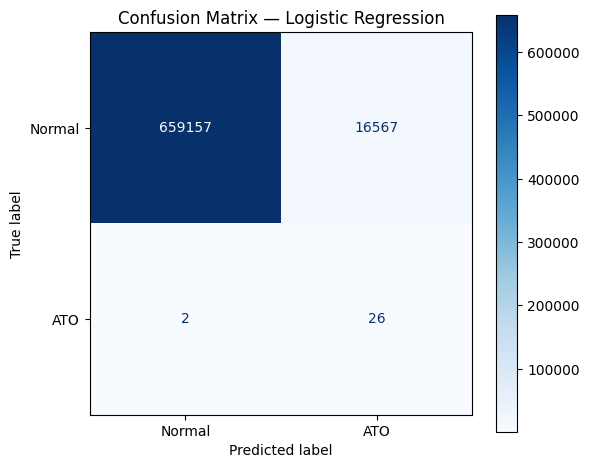

True Positives  (ATO correctly caught):   26
False Negatives (ATO missed):             2
False Positives (Normal flagged as ATO):  16567
True Negatives  (Normal correctly passed):659157


In [43]:
# Confusion matrix — shows True Positives, False Positives etc.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Normal', 'ATO'],
    cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

# Quick explanation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'True Positives  (ATO correctly caught):   {tp}')
print(f'False Negatives (ATO missed):             {fn}')
print(f'False Positives (Normal flagged as ATO):  {fp}')
print(f'True Negatives  (Normal correctly passed):{tn}')

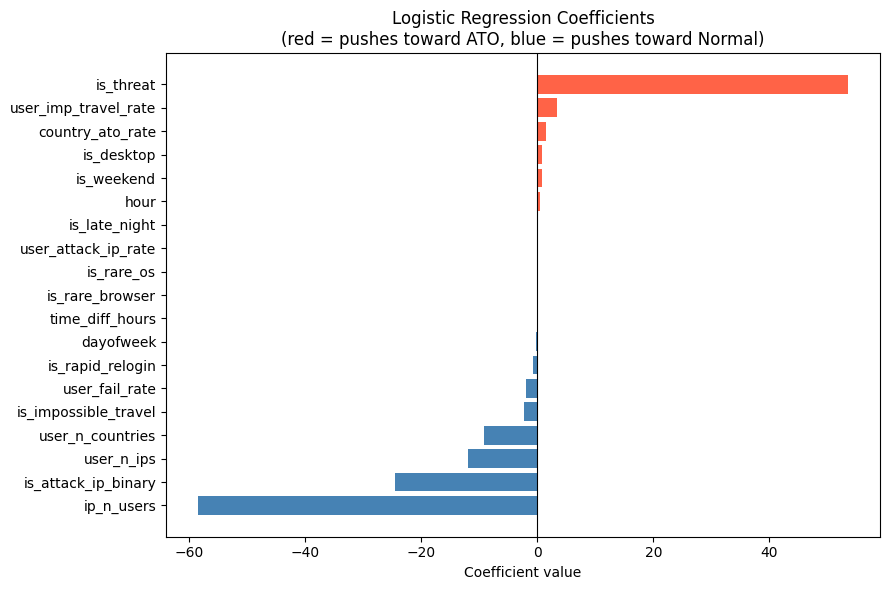

In [44]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(red = pushes toward ATO, blue = pushes toward Normal)')
plt.xlabel('Coefficient value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,          # prevents overfitting
    min_samples_leaf=5,    # each leaf needs at least 5 samples
    n_jobs=-1,             # use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)  # no scaling needed for RF

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [47]:
y_pred = rf.predict(X_test)
score = rf.score(X_test, y_test)
print(score)
print(classification_report(y_test, y_pred, digits=3))

0.9984728125110988
              precision    recall  f1-score   support

       False      1.000     0.998     0.999    675724
        True      0.018     0.679     0.036        28

    accuracy                          0.998    675752
   macro avg      0.509     0.839     0.517    675752
weighted avg      1.000     0.998     0.999    675752



=== Random Forest Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    675724
         ATO       0.02      0.68      0.04        28

    accuracy                           1.00    675752
   macro avg       0.51      0.84      0.52    675752
weighted avg       1.00      1.00      1.00    675752

ROC-AUC Score: 0.9939
PR-AUC Score (Precision-Recall): 0.3458


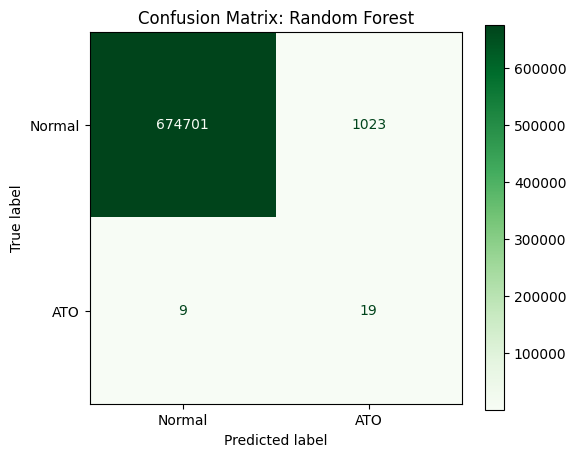

In [48]:
# 1. Generate predictions and probabilities
# Note: RF does not require the scaled data used for Logistic Regression
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1] 

# 2. Print Classification Report
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'ATO']))

# 3. Print specialized metrics for imbalanced data
roc_auc = roc_auc_score(y_test, y_proba_rf)
pr_auc = average_precision_score(y_test, y_proba_rf)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score (Precision-Recall): {pr_auc:.4f}")

# 4. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, 
    display_labels=['Normal', 'ATO'], 
    cmap='Greens', 
    ax=ax
)
plt.title('Confusion Matrix: Random Forest')
plt.show()

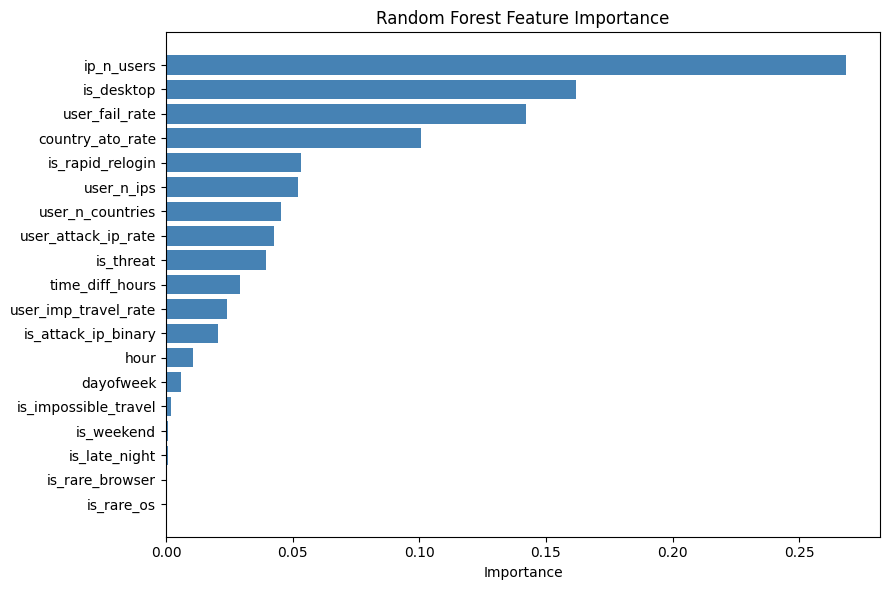

                 feature  importance
12            ip_n_users    0.268459
5             is_desktop    0.161678
14        user_fail_rate    0.142159
0       country_ato_rate    0.100563
10      is_rapid_relogin    0.053363
16            user_n_ips    0.052187
15      user_n_countries    0.045408
17   user_attack_ip_rate    0.042680
13             is_threat    0.039681
9        time_diff_hours    0.029068
18  user_imp_travel_rate    0.024128
11   is_attack_ip_binary    0.020560
1                   hour    0.010480
2              dayofweek    0.005890
8   is_impossible_travel    0.002083
4             is_weekend    0.000967
3          is_late_night    0.000644
7        is_rare_browser    0.000000
6             is_rare_os    0.000000


In [49]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance_df)